In [ ]:
#STEP 1: IMPORTING REQUIRED LIBRARIes


import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, Activation,
                                     MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import cv2
from PIL import Image


In [ ]:
#STEP 2: DEFINE CONFIGURATION VARIABLES

# Set all the paths and parameters

import splitfolders

# Original dataset location
input_folder = r"C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT"

# New folder to hold the split data
output_folder = r"C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT_split"

# Split dataset into 70% train, 20% validation, 10% test
splitfolders.ratio(input_folder, output=output_folder, seed=1337, ratio=(.7, .2, .1))





Copying files: 10112 files [01:00, 167.49 files/s]


In [ ]:
#Dataset Path Configuration and Parameter Initialization
import os

#  Use the new split dataset folder
DATA_DIR = r"C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT_split"

#  Define subfolder paths
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")
TEST_DIR  = os.path.join(DATA_DIR, "test")

#  Define parameters
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 30
MODEL_PATH = "best_model.h5"

#  Check the folder paths exist
for path in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(path, "->", os.path.exists(path))


C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT_split\train -> True
C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT_split\val -> True
C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT_split\test -> True


In [ ]:
!pip install split-folders




[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#STEP 3: CREATE DATA GENERATORS

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
print(train_gen.class_indices)

Found 8671 images belonging to 3 classes.
Found 5340 images belonging to 3 classes.
Found 4817 images belonging to 3 classes.
{'benign': 0, 'malignant': 1, 'normal': 2}


In [ ]:
# STEP 4: BUILD CNN MODEL FROM SCRATCH 

from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    Activation, Dropout, Dense, GlobalAveragePooling2D
)
from tensorflow.keras.models import Model


def build_cnn_from_scratch(input_shape=(128,128,3), num_classes=3, dropout_rate=0.4):
    inp = Input(shape=input_shape)

    # Block 1
    x = Conv2D(32, (3,3), padding="same")(inp)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = MaxPooling2D((2,2))(x)

    # Block 2
    x = Conv2D(64, (3,3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = MaxPooling2D((2,2))(x)

    # Block 3
    x = Conv2D(128, (3,3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = MaxPooling2D((2,2))(x)

    # Block 4
    x = Conv2D(256, (3,3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = MaxPooling2D((2,2))(x)

    # Output head
    x = GlobalAveragePooling2D()(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=inp, outputs=out)
    return model


# IMPORTANT: use generator class count
model = build_cnn_from_scratch(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=train_gen.num_classes
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 423,619 (1.62 MB)

 Trainable params: 422,659 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# STEP 5: COMPILE AND TRAIN MODEL 

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
import os

# SETTINGS 
IMG_SIZE = (128, 128)        # Smaller images = faster training
EPOCHS = 10                  # Reduced epochs
BATCH_SIZE = 32
MODEL_PATH = "model/best_model.h5"

# BUILD MODEL USING TRANSFER LEARNING
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(3, activation='softmax')(x)  # 3 classes (Normal, Benign, Malignant)
model = Model(inputs=base_model.input, outputs=x)

# Freeze base model layers for speed
for layer in base_model.layers:
    layer.trainable = False

# COMPILE MODEL 
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30
)

# CALLBACKS 
checkpoint = ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True, mode='max')
earlystop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

# TRAIN DATA GENERATORS 
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Automatically split 80% train, 20% validation
)

train_gen = train_datagen.flow_from_directory(
    'Dataset_BUSI_with_GT_split/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    'Dataset_BUSI_with_GT_split/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# TRAIN MODEL 
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[checkpoint, earlystop, reduce_lr],
    verbose=1
)

print(" Training complete! Best model saved at:", os.path.abspath(MODEL_PATH))



c:\Users\zaina\Downloads\AI DISEASE PREDICTION\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 235s 836ms/step - accuracy: 0.8285 - loss: 0.4042 - val_accuracy: 0.8968 - val_loss: 0.2755
Epoch 2/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 152s 562ms/step - accuracy: 0.9198 - loss: 0.2211 - val_accuracy: 0.9285 - val_loss: 0.1850
Epoch 3/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 144s 533ms/step - accuracy: 0.9428 - loss: 0.1696 - val_accuracy: 0.9333 - val_loss: 0.1626
Epoch 4/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 151s 557ms/step - accuracy: 0.9592 - loss: 0.1339 - val_accuracy: 0.9592 - val_loss: 0.1239
Epoch 5/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 147s 542ms/step - accuracy: 0.9676 - loss: 0.1114 - val_accuracy: 0.9693 - val_loss: 0.1082
Epoch 6/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 147s 544ms/step - accuracy: 0.9781 - loss: 0.0927 - val_accuracy: 0.9813 - val_loss: 0.0892
Epoch 7/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 146s 537ms/step - accuracy: 0.9827 - loss: 0.0806 - val_accuracy: 0.9755 - val_loss: 0.0855
Epoch 8/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 146s 537ms/step - accuracy: 0.9873 -

217/217 ━━━━━━━━━━━━━━━━━━━━ 95s 437ms/step - accuracy: 0.9988 - loss: 0.0084 - val_accuracy: 1.0000 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 2/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 92s 425ms/step - accuracy: 0.9994 - loss: 0.0068 - val_accuracy: 1.0000 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 3/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 92s 423ms/step - accuracy: 0.9996 - loss: 0.0059 - val_accuracy: 1.0000 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 4/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 93s 428ms/step - accuracy: 0.9996 - loss: 0.0057 - val_accuracy: 1.0000 - val_loss: 0.0087 - learning_rate: 5.0000e-04
 Training complete! Best model saved at: c:\Users\zaina\Downloads\AI DISEASE PREDICTION\model\best_model.h5


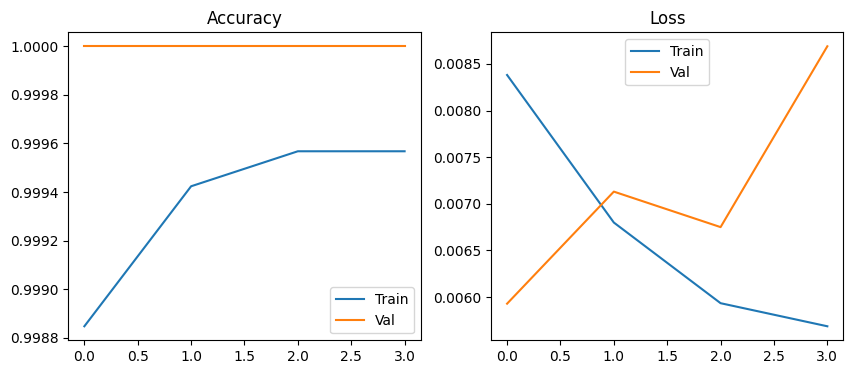

In [ ]:
#Step 6 — Plot Training History

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.show()


55/55 ━━━━━━━━━━━━━━━━━━━━ 24s 379ms/step
Class indices mapping: {'benign': 0, 'malignant': 1, 'normal': 2}
Class names in order: ['benign', 'malignant', 'normal']
Classification Report:

              precision    recall  f1-score   support

      benign       0.35      0.35      0.35       608
   malignant       0.34      0.34      0.34       575
      normal       0.30      0.30      0.30       549

    accuracy                           0.33      1732
   macro avg       0.33      0.33      0.33      1732
weighted avg       0.33      0.33      0.33      1732



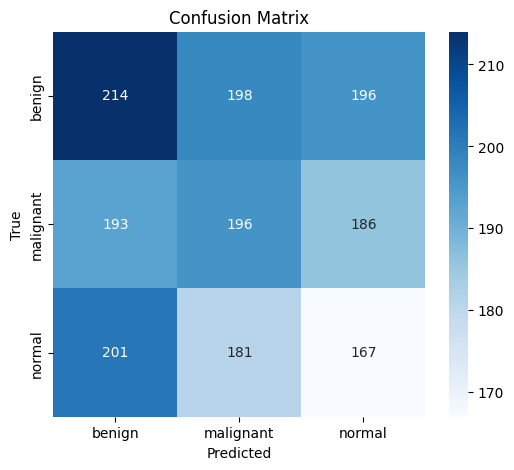

In [ ]:
#Step 7 — Evaluation & Classification Report


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

# Load the best saved model
model = tf.keras.models.load_model(MODEL_PATH)

# Reset the validation generator
val_gen.reset()

# Predict on validation set
preds = model.predict(val_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)

# True labels
y_true = val_gen.classes  # This must be used, NOT class_indices

# Check mapping of class names
print("Class indices mapping:", val_gen.class_indices)
# Adjust CLASSES to match the order of class_indices
CLASSES = [k for k, v in sorted(val_gen.class_indices.items(), key=lambda item: item[1])]
print("Class names in order:", CLASSES)

# Classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASSES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()




In [ ]:
import numpy as np
import cv2
from PIL import Image
import tensorflow as tf

CLASSES = ["benign", "malignant", "normal"]



def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Model mapping input to last conv layer output + predictions
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Compute gradients
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    # Reshape pooled_grads for broadcasting
    pooled_grads = tf.reshape(pooled_grads, (1, 1, -1))
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    # Normalize heatmap
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-10

    return heatmap.numpy()


def display_gradcam(image_path, model, last_conv_layer_name):
    # Load and preprocess image
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((224, 224))
    img_array = np.expand_dims(np.array(img_resized)/255.0, axis=0)

    # Prediction
    preds = model.predict(img_array)
    pred_class = np.argmax(preds)

    # Generate Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=pred_class)
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Overlay heatmap on original image
    img_uint8 = np.array(img_resized, dtype=np.uint8)
    overlay = cv2.addWeighted(img_uint8, 0.6, heatmap, 0.4, 0)
    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    return overlay, CLASSES[pred_class] 





1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


c:\Users\zaina\Downloads\AI DISEASE PREDICTION\venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


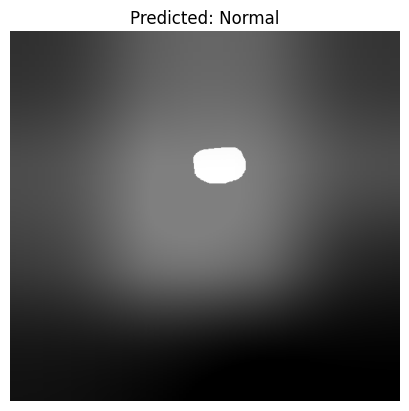

In [ ]:
#GRAD-CAM VISUALIZATION FOR CNN MODEL PREDICTION
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import Model

# Step 1: Define dataset folder, last conv layer name, and class names 
DATA_DIR = r"C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT_split\test"
last_conv_layer_name = "Conv_1"   # Change to your model's actual last conv layer name
class_names = ["Normal", "Benign", "Malignant"]

# Step 2: Automatically get first image from dataset folder 
test_image_path = None
for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            test_image_path = os.path.join(root, file)
            break
    if test_image_path:
        break

if not test_image_path:
    raise FileNotFoundError("No image found in the dataset folder!")

# Step 3: Define display_gradcam function 
def display_gradcam(image_path, model, last_conv_layer_name):
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((128, 128))
    img_array = np.expand_dims(np.array(img_resized)/255.0, axis=0)

    # Prediction
    preds = model.predict(img_array)
    pred_class = np.argmax(preds)
    predicted_label = class_names[pred_class]

    # Grad-CAM
    grad_model = Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, pred_class]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0].numpy()
    for i in range(conv_outputs.shape[-1]):
        conv_outputs[:, :, i] *= pooled_grads[i].numpy()

    heatmap = np.mean(conv_outputs, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) if np.max(heatmap) != 0 else 1

    heatmap = np.uint8(255 * heatmap)
    heatmap = Image.fromarray(heatmap).resize(img.size)
    heatmap = np.array(heatmap)

    overlay = np.array(img)
    overlay = np.uint8(0.5 * overlay + 0.5 * np.stack([heatmap]*3, axis=-1))

    return overlay, predicted_label

# Step 4: Generate Grad-CAM and display 
overlay, predicted_label = display_gradcam(test_image_path, model, last_conv_layer_name)

plt.imshow(overlay)
plt.title(f"Predicted: {predicted_label}")
plt.axis('off')
plt.show()


In [ ]:
for layer in model.layers:
    if 'conv' in layer.name:
        print(layer.name)


expanded_conv_depthwise
expanded_conv_depthwise_BN
expanded_conv_depthwise_relu
expanded_conv_project
expanded_conv_project_BN


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Predicted Class: malignant
Class Probabilities: {'benign': np.float32(4.210618e-07), 'malignant': np.float32(0.9999995), 'normal': np.float32(8.656517e-09)}


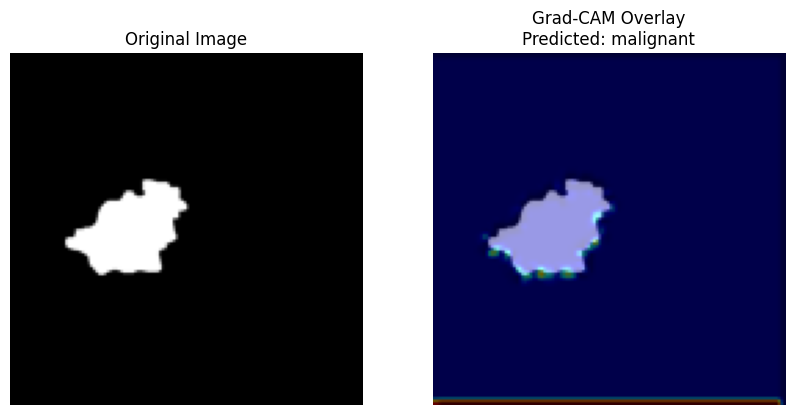

In [ ]:
#USER INPUT IMAGE PREDICTION WITH GRAD-CAM VISUALIZATION
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import numpy as np
import tensorflow as tf

# Make sure CLASSES matches training generator order
CLASSES = list(train_gen.class_indices.keys())  # ['normal', 'benign', 'malignant']

# Ask user for image path
test_image_path = input("Enter the full path of the image: ")

# Function to generate Grad-CAM heatmap
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0].numpy()

    for i in range(conv_outputs.shape[-1]):
        conv_outputs[:,:,i] *= pooled_grads[i].numpy()

    heatmap = np.mean(conv_outputs, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) if np.max(heatmap) != 0 else 1
    return heatmap

# Function to predict and generate Grad-CAM overlay
def display_gradcam(image_path, model, last_conv_layer_name):
    # Load and preprocess image
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((128,128))  # Resize to model input size
    img_array = np.expand_dims(np.array(img_resized)/255.0, axis=0)

    # Predict class
    preds = model.predict(img_array)
    pred_class = np.argmax(preds)

    # Generate Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=pred_class)
    heatmap = cv2.resize(heatmap, (128,128))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Overlay heatmap on original image
    img_uint8 = np.array(img_resized, dtype=np.uint8)
    overlay = cv2.addWeighted(img_uint8, 0.6, heatmap, 0.4, 0)
    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    return overlay, preds

# Get last conv layer automatically
last_conv_layer_name = [layer.name for layer in model.layers if 'conv' in layer.name][-1]

# Predict and display
overlay, preds = display_gradcam(test_image_path, model, last_conv_layer_name)
pred_idx = np.argmax(preds)
predicted_label = CLASSES[pred_idx]

print(f"Predicted Class: {predicted_label}")
print(f"Class Probabilities: {dict(zip(CLASSES, preds[0]))}")

# Display original and overlay
img = Image.open(test_image_path).convert("RGB")
img_resized = img.resize((128,128))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_resized)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(overlay)
plt.title(f"Grad-CAM Overlay\nPredicted: {predicted_label}")
plt.axis("off")

plt.show()


c:\Users\zaina\Downloads\AI DISEASE PREDICTION\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


151/151 ━━━━━━━━━━━━━━━━━━━━ 72s 479ms/step


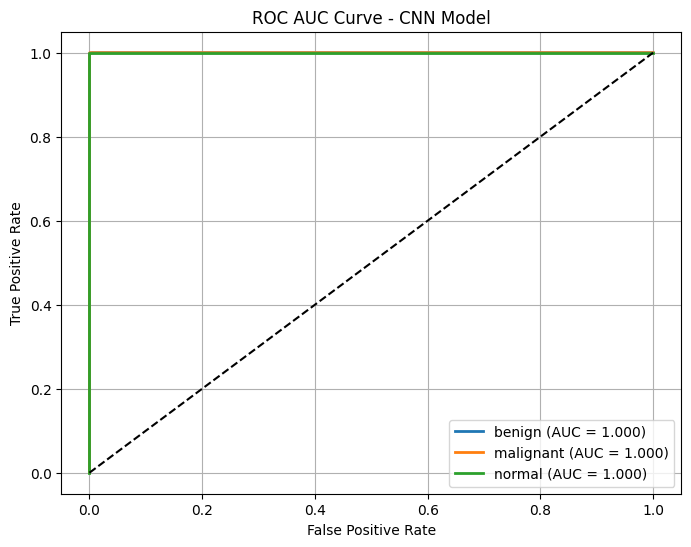

In [ ]:
# ROC-AUC CURVE

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Reset generator
test_gen.reset()

# Get predictions
y_pred_prob = model.predict(test_gen, verbose=1)

# True labels
y_true = test_gen.classes

# Number of classes
n_classes = len(test_gen.class_indices)

# Convert true labels to binary format
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

# Plot ROC curve for each class
plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2,
             label=f'{list(test_gen.class_indices.keys())[i]} (AUC = {roc_auc:.3f})')

# Random line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC AUC Curve - CNN Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator
#  Define test data generator

test_datagen = ImageDataGenerator(rescale=1./255)  # Only rescale, no augmentation

# Path to test dataset
test_dir = r"C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT_split\test"

# Create test generator
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128,128),   
    batch_size=32,
    class_mode='categorical',
    shuffle=False             


# Evaluate model

loss, accuracy = model.evaluate(test_gen, verbose=1)

print(f"Test Accuracy: {accuracy*100:.2f}%")
)

Found 4817 images belonging to 3 classes.


c:\Users\zaina\Downloads\AI DISEASE PREDICTION\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


151/151 ━━━━━━━━━━━━━━━━━━━━ 57s 341ms/step - accuracy: 0.9996 - loss: 0.0069
Test Accuracy: 99.96%


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predict labels
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))


151/151 ━━━━━━━━━━━━━━━━━━━━ 50s 333ms/step
[[1686    2    0]
 [   0 1604    0]
 [   0    0 1525]]
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00      1688
   malignant       1.00      1.00      1.00      1604
      normal       1.00      1.00      1.00      1525

    accuracy                           1.00      4817
   macro avg       1.00      1.00      1.00      4817
weighted avg       1.00      1.00      1.00      4817



In [ ]:
# UNIVERSAL AUC CALCULATION 

from sklearn.metrics import roc_auc_score
import numpy as np
from tensorflow.keras.preprocessing.image import DirectoryIterator

# Safe scan for ANY generator (validation/test) 
val_gen = None

# Convert globals().items() to list to avoid RuntimeError
for var_name, value in list(globals().items()):
    if isinstance(value, DirectoryIterator):
        if "val" in var_name.lower() or "test" in var_name.lower():
            val_gen = value
            print(f" Found validation/test generator: {var_name}")
            break

# If still not found, pick ANY DirectoryIterator
if val_gen is None:
    for var_name, value in list(globals().items()):
        if isinstance(value, DirectoryIterator):
            val_gen = value
            print(f"⚠ Using fallback generator: {var_name}")
            break

if val_gen is None:
    raise NameError("No DirectoryIterator (ImageDataGenerator) found!")

# Collect predictions 
val_gen.reset()
y_true = []
y_pred = []

for batch_imgs, batch_labels in val_gen:
    preds = model.predict(batch_imgs, verbose=0)
    y_pred.extend(preds)
    y_true.extend(batch_labels)

    if len(y_true) >= val_gen.samples:
        break

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute AUC
auc = roc_auc_score(y_true, y_pred, multi_class="ovr")

print("\n AUC Score:", round(auc, 4))
print(" AUC Percentage:", round(auc * 100, 2), "%")
print(" AUC Computed Successfully")



 Found validation/test generator: test_gen



 AUC Score: 1.0
 AUC Percentage: 100.0 %
 AUC Computed Successfully


In [ ]:
import os

# create folder if not exists
os.makedirs("model", exist_ok=True)

# save cnn model
model.save("best_model.h5")

print(" CNN model saved as model/best_model.h5")


 CNN model saved as model/best_model.h5


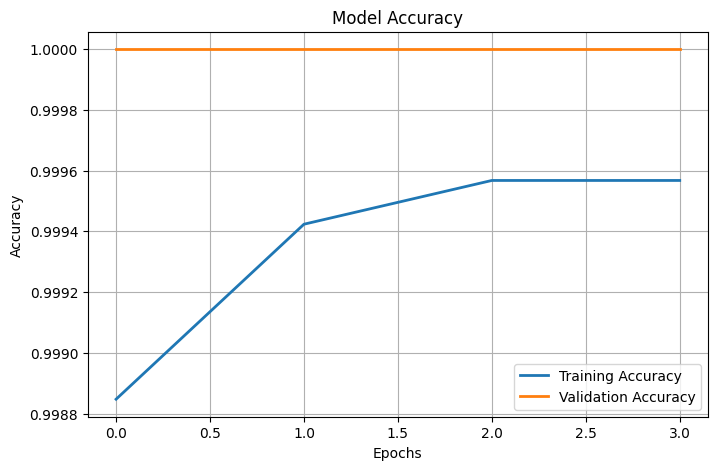

In [ ]:
# MODEL ACCURACY PLOT

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], linewidth=2, label='Training Accuracy')
plt.plot(history.history['val_accuracy'], linewidth=2, label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

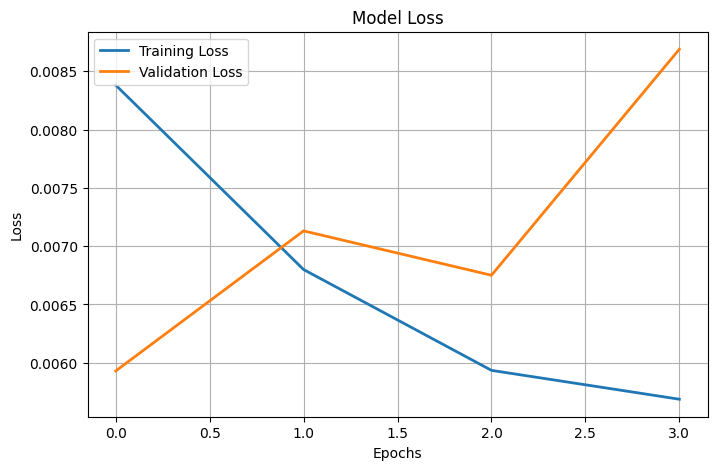

In [ ]:
# MODEL LOSS PLOT

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], linewidth=2, label='Training Loss')
plt.plot(history.history['val_loss'], linewidth=2, label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# CNN + XAI MODEL ACCURACY PERCENTAGE

test_loss, test_accuracy = model.evaluate(test_gen, verbose=1)

print(f"Model Accuracy: {test_accuracy * 100:.2f}%")

151/151 ━━━━━━━━━━━━━━━━━━━━ 50s 327ms/step - accuracy: 0.9996 - loss: 0.0069
Model Accuracy: 99.96%


In [ ]:
#save model
import os

# create folder if not exists
os.makedirs("model", exist_ok=True)

#save cnn model
model.save("best_model.h5")

print(" CNN Model saved as model/best_model.h5")

 CNN Model saved as model/best_model.h5
